# Decision Tree Classification & Overfitting Boundaries

Decision Trees partition feature spaces recursively along orthogonal boundaries. Controlling the tree depth is essential: shallow trees underfit, while deep trees overfit noisy patterns. This notebook generates a non-linear dataset (concentric circles with noise), trains Decision Trees with varying max depths, and visualizes the resulting decision boundaries using Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Generate a synthetic non-linear dataset (2 concentric circles with noise)
np.random.seed(45)
n_samples = 400

# Inner circle
r_inner = np.random.uniform(0.0, 0.4, n_samples // 2)
theta_inner = np.random.uniform(0, 2*np.pi, n_samples // 2)
X_inner = np.column_stack((r_inner * np.cos(theta_inner), r_inner * np.sin(theta_inner)))
y_inner = np.zeros(n_samples // 2)

# Outer circle
r_outer = np.random.uniform(0.6, 1.0, n_samples // 2)
theta_outer = np.random.uniform(0, 2*np.pi, n_samples // 2)
X_outer = np.column_stack((r_outer * np.cos(theta_outer), r_outer * np.sin(theta_outer)))
y_outer = np.ones(n_samples // 2)

# Combine and add noise
X = np.vstack((X_inner, X_outer)) + np.random.normal(0, 0.1, (n_samples, 2))
y = np.concatenate((y_inner, y_outer))

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['Class'] = y.astype(int)
df.head(10)



,Feature_1,Feature_2,Class
0,-0.000671,-0.410064,0
1,0.037699,-0.106386,0
2,-0.087690,-0.099829,0
3,-0.027856,-0.024616,0
4,0.092442,-0.069838,0
5,-0.016622,-0.261239,0
6,0.076783,0.071792,0
7,0.055536,-0.059632,0
8,-0.193354,-0.059615,0
9,0.234491,-0.084780,0


## Decision Boundary Visualization Helper

We implement a function to plot decision boundaries. It evaluates the trained model on a dense grid of points covering the coordinate space.



In [2]:
def plot_boundaries(ax, model, X, y, title):
    # Set boundaries
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    
    # Generate coordinates grid
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Predict classes
    predictions = model.predict(grid_points)
    predictions = predictions.reshape(xx.shape)
    
    # Plot contours
    ax.contourf(xx, yy, predictions, alpha=0.3, cmap='coolwarm')
    
    # Scatter points colored by class
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=30, alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, linestyle=':', alpha=0.6)



## Decision Trees Training & Comparison

We partition our dataset into 80/20 segments, and train three Decision Tree models with maximum depths set to 2, 4, and Unlimited respectively. We print the test set accuracies and draw decision boundary subplots.



Test Set Performance Metrics:
Max Depth = 2 Accuracy: 80.00% (Underfitting)
Max Depth = 4 Accuracy: 93.75% (Balanced / Optimal)
Max Depth = None Accuracy: 93.75% (Overfitting)


<cell>:30: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



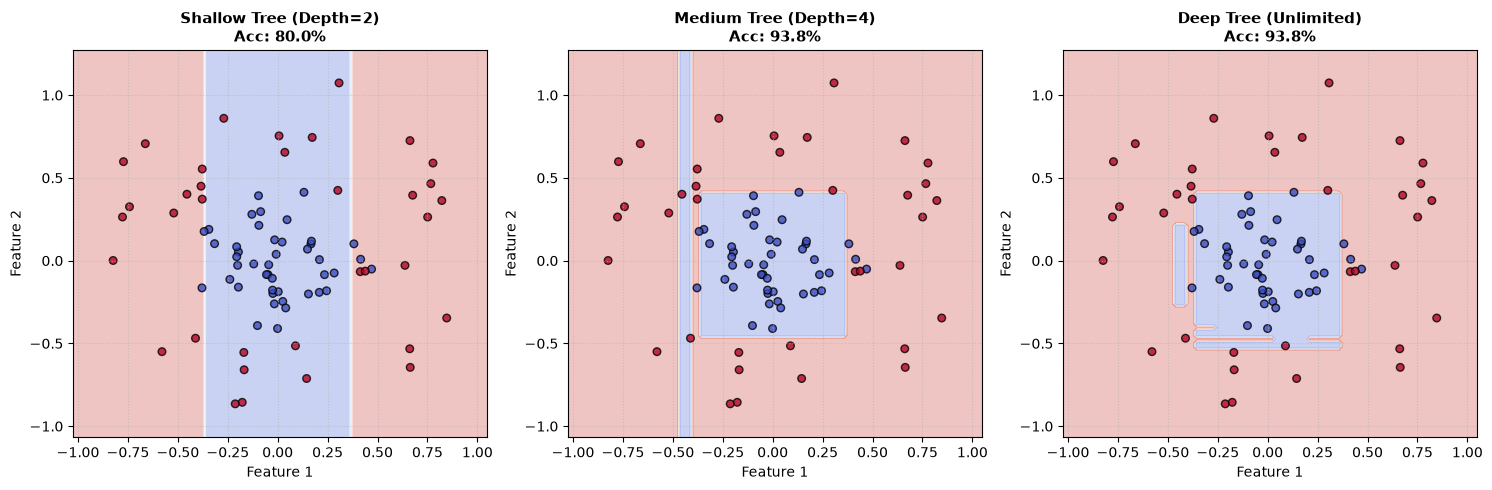

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train tree models
tree_shallow = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_medium = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_deep = DecisionTreeClassifier(max_depth=None, random_state=42) # Overfitting tree

tree_shallow.fit(X_train, y_train)
tree_medium.fit(X_train, y_train)
tree_deep.fit(X_train, y_train)

# Evaluate accuracies
acc_shallow = tree_shallow.score(X_test, y_test)
acc_medium = tree_medium.score(X_test, y_test)
acc_deep = tree_deep.score(X_test, y_test)

print(f"Test Set Performance Metrics:")
print(f"Max Depth = 2 Accuracy: {acc_shallow*100:.2f}% (Underfitting)")
print(f"Max Depth = 4 Accuracy: {acc_medium*100:.2f}% (Balanced / Optimal)")
print(f"Max Depth = None Accuracy: {acc_deep*100:.2f}% (Overfitting)")

# Plot side-by-side boundaries
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_boundaries(axes[0], tree_shallow, X_test, y_test, f"Shallow Tree (Depth=2)\nAcc: {acc_shallow*100:.1f}%")
plot_boundaries(axes[1], tree_medium, X_test, y_test, f"Medium Tree (Depth=4)\nAcc: {acc_medium*100:.1f}%")
plot_boundaries(axes[2], tree_deep, X_test, y_test, f"Deep Tree (Unlimited)\nAcc: {acc_deep*100:.1f}%")

plt.tight_layout()
plt.show()
